In [125]:
import mlx.nn as nn
import mlx.core as mx

import cv2
import matplotlib.pyplot as plt
import numpy as np
from torchvision.transforms import Compose
from typing import Dict, List, Sequence, Callable, Optional, Tuple, Union, Any
from functools import partial
import math


In [11]:
rawInput = cv2.imread("assets/examples/demo01.jpg")

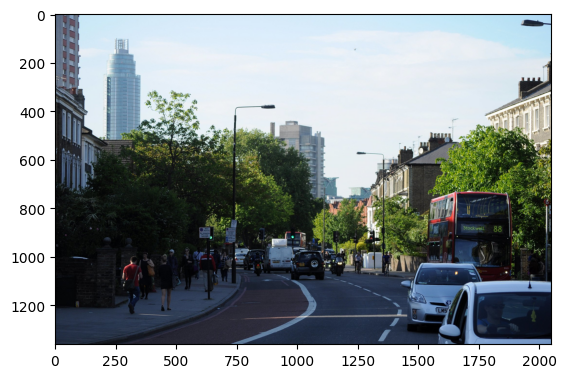

In [15]:
plt.imshow(cv2.cvtColor(rawInput, cv2.COLOR_BGR2RGB))

In [24]:
class Resize(object):
    """Resize sample to given size (width, height).
    """
    def __init__(
        self,
        width,
        height,
        resize_target=True,
        keep_aspect_ratio=False,
        ensure_multiple_of=1,
        resize_method="lower_bound",
        image_interpolation_method=cv2.INTER_AREA,
    ):
        self.__width = width
        self.__height = height

        self.__resize_target = resize_target
        self.__keep_aspect_ratio = keep_aspect_ratio
        self.__multiple_of = ensure_multiple_of
        self.__resize_method = resize_method
        self.__image_interpolation_method = image_interpolation_method

    def get_size(self, width, height):
        # determine new height and width
        scale_height = self.__height / height
        scale_width = self.__width / width

        if self.__keep_aspect_ratio:
            if self.__resize_method == "lower_bound":
                # scale such that output size is lower bound
                if scale_width > scale_height:
                    # fit width
                    scale_height = scale_width
                else:
                    # fit height
                    scale_width = scale_height
            elif self.__resize_method == "upper_bound":
                # scale such that output size is upper bound
                if scale_width < scale_height:
                    # fit width
                    scale_height = scale_width
                else:
                    # fit height
                    scale_width = scale_height
            elif self.__resize_method == "minimal":
                # scale as least as possbile
                if abs(1 - scale_width) < abs(1 - scale_height):
                    # fit width
                    scale_height = scale_width
                else:
                    # fit height
                    scale_width = scale_height
            else:
                raise ValueError(f"resize_method {self.__resize_method} not implemented")

        if self.__resize_method == "lower_bound":
            new_height = self.constrain_to_multiple_of(scale_height * height, min_val=self.__height)
            new_width = self.constrain_to_multiple_of(scale_width * width, min_val=self.__width)
        elif self.__resize_method == "upper_bound":
            new_height = self.constrain_to_multiple_of(scale_height * height, max_val=self.__height)
            new_width = self.constrain_to_multiple_of(scale_width * width, max_val=self.__width)
        elif self.__resize_method == "minimal":
            new_height = self.constrain_to_multiple_of(scale_height * height)
            new_width = self.constrain_to_multiple_of(scale_width * width)
        else:
            raise ValueError(f"resize_method {self.__resize_method} not implemented")

        return (new_width, new_height)
    
    def constrain_to_multiple_of(self, x, min_val=0, max_val=None):
        y = (np.round(x / self.__multiple_of) * self.__multiple_of).astype(int)

        if max_val is not None and y > max_val:
            y = (np.floor(x / self.__multiple_of) * self.__multiple_of).astype(int)

        if y < min_val:
            y = (np.ceil(x / self.__multiple_of) * self.__multiple_of).astype(int)

        return y
    def __call__(self, sample):
        width, height = self.get_size(sample["image"].shape[1], sample["image"].shape[0])
        
        # resize sample
        sample["image"] = cv2.resize(sample["image"], (width, height), interpolation=self.__image_interpolation_method)

        if self.__resize_target:
            if "depth" in sample:
                sample["depth"] = cv2.resize(sample["depth"], (width, height), interpolation=cv2.INTER_NEAREST)
                
            if "mask" in sample:
                sample["mask"] = cv2.resize(sample["mask"].astype(np.float32), (width, height), interpolation=cv2.INTER_NEAREST)
        
        return sample
class NormalizeImage(object):
    """Normlize image by given mean and std.
    """

    def __init__(self, mean, std):
        self.__mean = mean
        self.__std = std

    def __call__(self, sample):
        sample["image"] = (sample["image"] - self.__mean) / self.__std

        return sample


class PrepareForNet(object):
    """Prepare sample for usage as network input.
    """

    def __init__(self):
        pass

    def __call__(self, sample):
        image = np.transpose(sample["image"], (2, 0, 1))
        sample["image"] = np.ascontiguousarray(image).astype(np.float32)

        if "depth" in sample:
            depth = sample["depth"].astype(np.float32)
            sample["depth"] = np.ascontiguousarray(depth)
        
        if "mask" in sample:
            sample["mask"] = sample["mask"].astype(np.float32)
            sample["mask"] = np.ascontiguousarray(sample["mask"])
        
        return sample

In [25]:
class ComposeMLX:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, x):
        for t in self.transforms:
            x = t(x)
        return x

In [277]:
def make_2tuple(x):
    if isinstance(x, tuple):
        assert len(x) == 2
        return x

    assert isinstance(x, int)
    return (x, x)

class PatchEmbed(nn.Module):
    """
    2D image to patch embedding: (B,C,H,W) -> (B,N,D)

    Args:
        img_size: Image size.
        patch_size: Patch token size.
        in_chans: Number of input image channels.
        embed_dim: Number of linear projection output channels.
        norm_layer: Normalization layer.
    """

    def __init__(
        self,
        img_size: Union[int, Tuple[int, int]] = 224,
        patch_size: Union[int, Tuple[int, int]] = 16,
        in_chans: int = 3,
        embed_dim: int = 768,
        norm_layer: Optional[Callable] = None,
        flatten_embedding: bool = True,
    ) -> None:
        super().__init__()

        image_HW = make_2tuple(img_size)
        patch_HW = make_2tuple(patch_size)
        patch_grid_size = (
            image_HW[0] // patch_HW[0],
            image_HW[1] // patch_HW[1],
        )

        self.img_size = image_HW
        self.patch_size = patch_HW
        self.patches_resolution = patch_grid_size
        self.num_patches = patch_grid_size[0] * patch_grid_size[1]

        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.flatten_embedding = flatten_embedding

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_HW, stride=patch_HW)
        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def forward(self, x: mx.array) -> mx.array:
        _, _, H, W = x.shape
        patch_H, patch_W = self.patch_size

        assert H % patch_H == 0, f"Input image height {H} is not a multiple of patch height {patch_H}"
        assert W % patch_W == 0, f"Input image width {W} is not a multiple of patch width: {patch_W}"
        x = mx.transpose(x, (0, 2, 3, 1))  # Convert BCHW → BHWC for MLX conv
        x = self.proj(x)  # pytorch B C H W mlx BHWC
        x = mx.transpose(x, (0, 3, 1, 2)) # Convert BHWC → BCHW 

        H, W = x.shape[2], x.shape[3]
        x = x.flatten(2).transpose((0, 2, 1))  # B HW C
        x = self.norm(x)
        if not self.flatten_embedding:
            x = x.reshape(-1, H, W, self.embed_dim)  # B H W C
        return x
    def __call__(self, x: mx.array) -> mx.array:
        return self.forward(x)
    
    def flops(self) -> float:
        Ho, Wo = self.patches_resolution
        flops = Ho * Wo * self.embed_dim * self.in_chans * (self.patch_size[0] * self.patch_size[1])
        if self.norm is not None:
            flops += Ho * Wo * self.embed_dim
        return flops


In [278]:
try:
    from xformers.ops import memory_efficient_attention, unbind, fmha

    XFORMERS_AVAILABLE = True
except ImportError:
    print("xFormers not available")
    XFORMERS_AVAILABLE = False
class Attention(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int = 8,
        qkv_bias: bool = False,
        proj_bias: bool = True,
        attn_drop: float = 0.0,
        proj_drop: float = 0.0,
    ) -> None:
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim**-0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim, bias=proj_bias)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x: mx.array) -> mx.array:
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0] * self.scale, qkv[1], qkv[2]
        attn = q @ k.transpose(-2, -1)

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x
class MemEffAttention(Attention):
    def forward(self, x: mx.array, attn_bias=None) -> mx.array:
        if not XFORMERS_AVAILABLE:
            assert attn_bias is None, "xFormers is required for nested tensors usage"
            return super().forward(x)

        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)

        q, k, v = unbind(qkv, 2)

        x = memory_efficient_attention(q, k, v, attn_bias=attn_bias)
        x = x.reshape([B, N, C])

        x = self.proj(x)
        x = self.proj_drop(x)
        return x

xFormers not available


In [279]:

class Mlp(nn.Module):
    def __init__(
        self,
        in_features: int,
        hidden_features: Optional[int] = None,
        out_features: Optional[int] = None,
        act_layer: Callable[..., nn.Module] = nn.GELU,
        drop: float = 0.0,
        bias: bool = True,
    ) -> None:
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features, bias=bias)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features, bias=bias)
        self.drop = nn.Dropout(drop)

    def forward(self, x: mx.array) -> mx.array:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

In [280]:
def randperm_mlx(b, device=None):
    key = mx.random.key()

    if device is None:
        arr = mx.arange(b, dtype=mx.int32)
    else:
        arr = mx.arange(b, dtype=mx.int32, device=device)

    return mx.random.shuffle(arr, key)

In [281]:
def index_add_mlx(x, axis, index, values, alpha=1.0):
    # x shape: [..., N, ...]
    # index shape: [K]
    # values shape: same as x indexed on axis

    N = x.shape[axis]
    K = index.shape[0]

    # one-hot: shape [K, N]
    onehot = mx.equal(
        mx.expand_dims(index, axis=-1),
        mx.arange(N)
    )

    # expand onehot to broadcast with values
    # shape -> insert axis dimension for broadcasting
    for _ in range(values.ndim - onehot.ndim):
        onehot = mx.expand_dims(onehot, -1)

    # contributions: broadcast onehot * values
    contrib = onehot * values * alpha

    # reduce-sum along K dimension
    added = mx.sum(contrib, axis=0)

    return x + added

In [282]:
def drop_add_residual_stochastic_depth(
    x: mx.array,
    residual_func: Callable[[mx.array], mx.array],
    sample_drop_ratio: float = 0.0,
) -> mx.array:
    # 1) extract subset using permutation
    b, n, d = x.shape
    sample_subset_size = max(int(b * (1 - sample_drop_ratio)), 1)
    brange = (randperm_mlx(b, device=x.device))[:sample_subset_size]
    x_subset = x[brange]

    # 2) apply residual_func to get residual
    residual = residual_func(x_subset)

    x_flat = x.flatten(1)
    residual = residual.flatten(1)

    residual_scale_factor = b / sample_subset_size

    # 3) add the residual
    x_plus_residual = index_add_mlx(x_flat, 0, brange, residual.to(dtype=x.dtype), alpha=residual_scale_factor)
    return mx.reshape(x_plus_residual, x.shape)


def get_branges_scales(x, sample_drop_ratio=0.0):
    b, n, d = x.shape
    sample_subset_size = max(int(b * (1 - sample_drop_ratio)), 1)
    brange = (randperm_mlx(b, device=x.device))[:sample_subset_size]
    residual_scale_factor = b / sample_subset_size
    return brange, residual_scale_factor


def add_residual(x, brange, residual, residual_scale_factor, scaling_vector=None):
    if scaling_vector is None:
        x_flat = x.flatten(1)
        residual = residual.flatten(1)
        x_plus_residual = index_add_mlx(x_flat, 0, brange, residual.to(dtype=x.dtype), alpha=residual_scale_factor)
    else:
        x_plus_residual = scaled_index_add(
            x, brange, residual.to(dtype=x.dtype), scaling=scaling_vector, alpha=residual_scale_factor
        )
    return x_plus_residual


attn_bias_cache: Dict[Tuple, Any] = {}


def get_attn_bias_and_cat(x_list, branges=None):
    """
    this will perform the index select, cat the tensors, and provide the attn_bias from cache
    """
    batch_sizes = [b.shape[0] for b in branges] if branges is not None else [x.shape[0] for x in x_list]
    all_shapes = tuple((b, x.shape[1]) for b, x in zip(batch_sizes, x_list))
    if all_shapes not in attn_bias_cache.keys():
        seqlens = []
        for b, x in zip(batch_sizes, x_list):
            for _ in range(b):
                seqlens.append(x.shape[1])
        attn_bias = fmha.BlockDiagonalMask.from_seqlens(seqlens)
        attn_bias._batch_sizes = batch_sizes
        attn_bias_cache[all_shapes] = attn_bias

    if branges is not None:
        cat_tensors = index_select_cat([x.flatten(1) for x in x_list], branges).view(1, -1, x_list[0].shape[-1])
    else:
        tensors_bs1 = tuple(x.reshape([1, -1, *x.shape[2:]]) for x in x_list)
        cat_tensors = mx.concatenate(tensors_bs1, dim=1)

    return attn_bias_cache[all_shapes], cat_tensors


def drop_add_residual_stochastic_depth_list(
    x_list: List[mx.array],
    residual_func: Callable[[mx.array, Any], mx.array],
    sample_drop_ratio: float = 0.0,
    scaling_vector=None,
) -> mx.array:
    # 1) generate random set of indices for dropping samples in the batch
    branges_scales = [get_branges_scales(x, sample_drop_ratio=sample_drop_ratio) for x in x_list]
    branges = [s[0] for s in branges_scales]
    residual_scale_factors = [s[1] for s in branges_scales]

    # 2) get attention bias and index+concat the tensors
    attn_bias, x_cat = get_attn_bias_and_cat(x_list, branges)

    # 3) apply residual_func to get residual, and split the result
    residual_list = attn_bias.split(residual_func(x_cat, attn_bias=attn_bias))  # type: ignore

    outputs = []
    for x, brange, residual, residual_scale_factor in zip(x_list, branges, residual_list, residual_scale_factors):
        outputs.append(add_residual(x, brange, residual, residual_scale_factor, scaling_vector).view_as(x))
    return outputs

In [283]:
def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)  # work with diff dim tensors, not just 2D ConvNets
    random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
    if keep_prob > 0.0:
        random_tensor.div_(keep_prob)
    output = x * random_tensor
    return output


class DropPath(nn.Module):
    """Drop paths (Stochastic Depth) per sample (when applied in main path of residual blocks)."""

    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)


In [284]:
class Block(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int,
        mlp_ratio: float = 4.0,
        qkv_bias: bool = False,
        proj_bias: bool = True,
        ffn_bias: bool = True,
        drop: float = 0.0,
        attn_drop: float = 0.0,
        init_values=None,
        drop_path: float = 0.0,
        act_layer: Callable[..., nn.Module] = nn.GELU,
        norm_layer: Callable[..., nn.Module] = nn.LayerNorm,
        attn_class: Callable[..., nn.Module] = Attention,
        ffn_layer: Callable[..., nn.Module] = Mlp,
    ) -> None:
        super().__init__()
        # print(f"biases: qkv: {qkv_bias}, proj: {proj_bias}, ffn: {ffn_bias}")
        self.norm1 = norm_layer(dim)
        self.attn = attn_class(
            dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            proj_bias=proj_bias,
            attn_drop=attn_drop,
            proj_drop=drop,
        )
        self.ls1 = LayerScale(dim, init_values=init_values) if init_values else nn.Identity()
        self.drop_path1 = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = ffn_layer(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=act_layer,
            drop=drop,
            bias=ffn_bias,
        )
        self.ls2 = LayerScale(dim, init_values=init_values) if init_values else nn.Identity()
        self.drop_path2 = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

        self.sample_drop_ratio = drop_path

    def forward(self, x: mx.array) -> mx.array:
        def attn_residual_func(x: mx.array) -> mx.array:
            return self.ls1(self.attn(self.norm1(x)))

        def ffn_residual_func(x: mx.array) -> mx.array:
            return self.ls2(self.mlp(self.norm2(x)))

        if self.training and self.sample_drop_ratio > 0.1:
            # the overhead is compensated only for a drop path rate larger than 0.1
            x = drop_add_residual_stochastic_depth(
                x,
                residual_func=attn_residual_func,
                sample_drop_ratio=self.sample_drop_ratio,
            )
            x = drop_add_residual_stochastic_depth(
                x,
                residual_func=ffn_residual_func,
                sample_drop_ratio=self.sample_drop_ratio,
            )
        elif self.training and self.sample_drop_ratio > 0.0:
            x = x + self.drop_path1(attn_residual_func(x))
            x = x + self.drop_path1(ffn_residual_func(x))  # FIXME: drop_path2
        else:
            x = x + attn_residual_func(x)
            x = x + ffn_residual_func(x)
        return x
    
class LayerScale(nn.Module):
    def __init__(
        self,
        dim: int,
        init_values: Union[float, mx.array] = 1e-5,
        inplace: bool = False,
    ) -> None:
        super().__init__()
        self.inplace = inplace
        self.gamma = (init_values * mx.ones(dim))

    def forward(self, x: mx.array) -> mx.array:
        return x.mul_(self.gamma) if self.inplace else x * self.gamma

class NestedTensorBlock(Block):
    def forward_nested(self, x_list: List[mx.array]) -> List[mx.array]:
        """
        x_list contains a list of tensors to nest together and run
        """
        assert isinstance(self.attn, MemEffAttention)

        if self.training and self.sample_drop_ratio > 0.0:

            def attn_residual_func(x: mx.array, attn_bias=None) -> mx.array:
                return self.attn(self.norm1(x), attn_bias=attn_bias)

            def ffn_residual_func(x: mx.array, attn_bias=None) -> mx.array:
                return self.mlp(self.norm2(x))

            x_list = drop_add_residual_stochastic_depth_list(
                x_list,
                residual_func=attn_residual_func,
                sample_drop_ratio=self.sample_drop_ratio,
                scaling_vector=self.ls1.gamma if isinstance(self.ls1, LayerScale) else None,
            )
            x_list = drop_add_residual_stochastic_depth_list(
                x_list,
                residual_func=ffn_residual_func,
                sample_drop_ratio=self.sample_drop_ratio,
                scaling_vector=self.ls2.gamma if isinstance(self.ls1, LayerScale) else None,
            )
            return x_list
        else:

            def attn_residual_func(x: mx.array, attn_bias=None) -> mx.array:
                return self.ls1(self.attn(self.norm1(x), attn_bias=attn_bias))

            def ffn_residual_func(x: mx.array, attn_bias=None) -> mx.array:
                return self.ls2(self.mlp(self.norm2(x)))

            attn_bias, x = get_attn_bias_and_cat(x_list)
            x = x + attn_residual_func(x, attn_bias=attn_bias)
            x = x + ffn_residual_func(x)
            return attn_bias.split(x)

    def forward(self, x_or_x_list):
        if isinstance(x_or_x_list, mx.array):
            return super().forward(x_or_x_list)
        elif isinstance(x_or_x_list, list):
            assert XFORMERS_AVAILABLE, "Please install xFormers for nested tensors usage"
            return self.forward_nested(x_or_x_list)
        else:
            raise AssertionError

In [285]:
class SwiGLUFFN(nn.Module):
    def __init__(
        self,
        in_features: int,
        hidden_features: Optional[int] = None,
        out_features: Optional[int] = None,
        act_layer: Callable[..., nn.Module] = None,
        drop: float = 0.0,
        bias: bool = True,
    ) -> None:
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.w12 = nn.Linear(in_features, 2 * hidden_features, bias=bias)
        self.w3 = nn.Linear(hidden_features, out_features, bias=bias)

    def forward(self, x: mx.array) -> mx.array:
        x12 = self.w12(x)
        x1, x2 = x12.chunk(2, dim=-1)
        hidden = F.silu(x1) * x2
        return self.w3(hidden)


try:
    from xformers.ops import SwiGLU

    XFORMERS_AVAILABLE = True
except ImportError:
    SwiGLU = SwiGLUFFN
    XFORMERS_AVAILABLE = False


class SwiGLUFFNFused(SwiGLU):
    def __init__(
        self,
        in_features: int,
        hidden_features: Optional[int] = None,
        out_features: Optional[int] = None,
        act_layer: Callable[..., nn.Module] = None,
        drop: float = 0.0,
        bias: bool = True,
    ) -> None:
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        hidden_features = (int(hidden_features * 2 / 3) + 7) // 8 * 8
        super().__init__(
            in_features=in_features,
            hidden_features=hidden_features,
            out_features=out_features,
            bias=bias,
        )


In [286]:
import logging
logger = logging.getLogger("dinov2")


def named_children_mlx(module):
    """
    Yields (name, child_module) for all nn.Module children in MLX.
    """
    for name, value in module.__dict__.items():
        if isinstance(value, nn.Module):
            yield name, value
        elif isinstance(value, (list, tuple)):
            # For lists of submodules (like ModuleList)
            for i, v in enumerate(value):
                if isinstance(v, nn.Module):
                    yield f"{name}.{i}", v
        elif isinstance(value, dict):
            # For dicts of submodules
            for k, v in value.items():
                if isinstance(v, nn.Module):
                    yield f"{name}.{k}", v

def named_apply(fn, module, name="", depth_first=True, include_root=False):
    """
    MLX version of PyTorch named_apply().
    Recursively applies fn(module=..., name=...) to all submodules.
    """

    # 1. If breadth-first and including root, visit root first
    if include_root and not depth_first:
        fn(module=module, name=name)

    # 2. Visit children recursively
    for child_name, child_module in named_children_mlx(module):
        full_name = f"{name}.{child_name}" if name else child_name
        named_apply(
            fn=fn,
            module=child_module,
            name=full_name,
            depth_first=depth_first,
            include_root=True,   # include all children
        )

    # 3. If depth-first and including root, visit root last
    if include_root and depth_first:
        fn(module=module, name=name)

    return module

# def named_apply(fn: Callable, module: nn.Module, name="", depth_first=True, include_root=False) -> nn.Module:
#     if not depth_first and include_root:
#         fn(module=module, name=name)
#     for child_name, child_module in module.named_children():
#         child_name = ".".join((name, child_name)) if name else child_name
#         named_apply(fn=fn, module=child_module, name=child_name, depth_first=depth_first, include_root=True)
#     if depth_first and include_root:
#         fn(module=module, name=name)
#     return module


class BlockChunk:
    def __init__(self, blocks):
        self.blocks = blocks

    def __call__(self, x):
        for b in self.blocks:
            x = b(x)
        return x

# class BlockChunk(nn.ModuleList):
#     def forward(self, x):
#         for b in self:
#             x = b(x)
#         return x

class ModuleList:
    def __init__(self, modules):
        self.modules = list(modules)

    def __iter__(self):
        return iter(self.modules)

    def __getitem__(self, idx):
        return self.modules[idx]

    def append(self, m):
        self.modules.append(m)

    def __len__(self):
        return len(self.modules)

    # MLX parameter support
    def parameters(self):
        return {"modules": self.modules}

# def trunc_normal_(shape, mean=0., std=1., a=-2., b=2.):
#     # Φ(a), Φ(b)
#     la = 0.5 * (1 + mx.erf(a / mx.sqrt(2)))
#     lb = 0.5 * (1 + mx.erf(b / mx.sqrt(2)))
#     print(shape)
#     # uniform between Φ(a) and Φ(b)
#     u = mx.random.uniform(shape=shape) * (lb - la) + la

#     # inverse CDF of normal
#     x = mx.sqrt(2) * mx.erfinv(2 * u - 1)

#     return x * std + mean
def trunc_normal_(var, mean=0., std=1., a=-2., b=2.):
    """
    MLX equivalent of torch.nn.init._no_grad_trunc_normal_.
    Returns a new tensor of same shape as `var`.
    """

    # Convert MLX shape → Python tuple of ints
    shape = tuple(int(s) for s in var.shape)

    # Compute lower & upper CDF bounds
    def norm_cdf(x):
        return (1.0 + math.erf(x / math.sqrt(2.0))) / 2.0

    l = norm_cdf((a - mean) / std)
    u = norm_cdf((b - mean) / std)

    # 1. Sample uniform in [l, u]
    # PyTorch: tensor.uniform_(2*l - 1, 2*u - 1)
    uniform = mx.random.uniform(shape=shape) * (u - l) + l

    # 2. Map uniform ∈ [l,u] → [2l-1, 2u-1]
    # This matches PyTorch’s "translate to [2l-1, 2u-1]"
    translated = uniform * 2.0 - 1.0

    # 3. Apply inverse error function → truncated standard normal
    # PyTorch: tensor.erfinv_()
    x = mx.erfinv(translated)

    # 4. Scale to match std & mean
    # PyTorch: tensor.mul_(std * sqrt(2)).add_(mean)
    x = x * (std * math.sqrt(2.0)) + mean

    # 5. Clamp to [a, b] as PyTorch does last
    # PyTorch: tensor.clamp_(min=a, max=b)
    x = mx.clip(x, a, b)

    return x

def init_weights_vit_timm(module: nn.Module, name: str = ""):
    """ViT weight initialization, original timm impl (for reproducibility)"""
    if isinstance(module, nn.Linear):
        trunc_normal_(module.weight, std=0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
def normal_mlx(var, mean=0.0, std=1.0):
    shape = tuple(int(s) for s in var.shape)  # MLX safe shape
    return mx.random.normal(shape) * std + mean

In [299]:
def resize_pos_embed(patch_pos_embed, sx, sy, antialias=True):
    B = 1
    N, D = patch_pos_embed.shape[1], patch_pos_embed.shape[2]
    sqrt_N = int(math.sqrt(N))

    # (1, H, W, C) for MLX
    x = mx.reshape(patch_pos_embed, (1, sqrt_N, sqrt_N, D))

    new_h = int(sqrt_N * sx)
    new_w = int(sqrt_N * sy)

    # Bicubic resize
    x = mx.image.resize(
        x,
        size=(new_h, new_w),
        method="cubic",
        antialias=antialias,
    )

    # Back to tokens: (1, new_N, D)
    x = mx.reshape(x, (1, new_h * new_w, D))
    return x

In [295]:
class DinoVisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_chans=3,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        qkv_bias=True,
        ffn_bias=True,
        proj_bias=True,
        drop_path_rate=0.0,
        drop_path_uniform=False,
        init_values=None,  # for layerscale: None or 0 => no layerscale
        embed_layer=PatchEmbed,
        act_layer=nn.GELU,
        block_fn=NestedTensorBlock,
        ffn_layer="mlp",
        block_chunks=1,
        num_register_tokens=0,
        interpolate_antialias=False,
        interpolate_offset=0.1,
    ):
        super().__init__()
        norm_layer = partial(nn.LayerNorm, eps=1e-6)

        self.num_features = self.embed_dim = embed_dim  # num_features for consistency with other models
        self.num_tokens = 1
        self.n_blocks = depth
        self.num_heads = num_heads
        self.patch_size = patch_size
        self.num_register_tokens = num_register_tokens
        self.interpolate_antialias = interpolate_antialias
        self.interpolate_offset = interpolate_offset

        self.patch_embed = embed_layer(img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = mx.zeros((1, 1, embed_dim))
        self.pos_embed = mx.zeros((1, num_patches + self.num_tokens, embed_dim))
        assert num_register_tokens >= 0
        self.register_tokens = (
            nn.Parameter(mx.zeros(1, num_register_tokens, embed_dim)) if num_register_tokens else None
        )

        if drop_path_uniform is True:
            dpr = [drop_path_rate] * depth
        else:
            dpr = [x.item() for x in mx.linspace(0, drop_path_rate, depth)]  # stochastic depth decay rule

        if ffn_layer == "mlp":
            logger.info("using MLP layer as FFN")
            ffn_layer = Mlp
        elif ffn_layer == "swiglufused" or ffn_layer == "swiglu":
            logger.info("using SwiGLU layer as FFN")
            ffn_layer = SwiGLUFFNFused
        elif ffn_layer == "identity":
            logger.info("using Identity layer as FFN")

            def f(*args, **kwargs):
                return nn.Identity()

            ffn_layer = f
        else:
            raise NotImplementedError

        blocks_list = [
            block_fn(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                proj_bias=proj_bias,
                ffn_bias=ffn_bias,
                drop_path=dpr[i],
                norm_layer=norm_layer,
                act_layer=act_layer,
                ffn_layer=ffn_layer,
                init_values=init_values,
            )
            for i in range(depth)
        ]
        if block_chunks > 0:
            self.chunked_blocks = True
            chunked_blocks = []
            chunksize = depth // block_chunks
            for i in range(0, depth, chunksize):
                # this is to keep the block index consistent if we chunk the block list
                chunked_blocks.append([nn.Identity()] * i + blocks_list[i : i + chunksize])
            self.blocks = ModuleList([BlockChunk(p) for p in chunked_blocks])
        else:
            self.chunked_blocks = False
            self.blocks = ModuleList(blocks_list)

        self.norm = norm_layer(embed_dim)
        self.head = nn.Identity()

        self.mask_token = mx.zeros((1, embed_dim))

        self.init_weights()

    def init_weights(self):
            trunc_normal_(self.pos_embed, std=0.02)
            normal_mlx(self.cls_token, std=1e-6)
            if self.register_tokens is not None:
                normal_mlx(self.register_tokens, std=1e-6)
            named_apply(init_weights_vit_timm, self)

    def interpolate_pos_encoding(self, x, w, h):
        previous_dtype = x.dtype
        npatch = x.shape[1] - 1
        N = self.pos_embed.shape[1] - 1
        if npatch == N and w == h:
            return self.pos_embed
        pos_embed = self.pos_embed.astype(mx.float32)
        class_pos_embed = pos_embed[:, 0:1]   # keep dims (B,1,D)
        patch_pos_embed = pos_embed[:, 1:]    # (B,N,D)

        dim = x.shape[-1]
        w0 = w // self.patch_size
        h0 = h // self.patch_size
        # we add a small number to avoid floating point error in the interpolation
        # see discussion at https://github.com/facebookresearch/dino/issues/8
        # DINOv2 with register modify the interpolate_offset from 0.1 to 0.0
        w0, h0 = w0 + self.interpolate_offset, h0 + self.interpolate_offset
        # w0, h0 = w0 + 0.1, h0 + 0.1
        
        sqrt_N = math.sqrt(N)
        sx, sy = float(w0) / sqrt_N, float(h0) / sqrt_N
        patch_pos_embed = nn.functional.interpolate(
            patch_pos_embed.reshape(1, int(sqrt_N), int(sqrt_N), dim).permute(0, 3, 1, 2),
            scale_factor=(sx, sy),
            # (int(w0), int(h0)), # to solve the upsampling shape issue
            mode="bicubic",
            antialias=self.interpolate_antialias
        )
        
        assert int(w0) == patch_pos_embed.shape[-2]
        assert int(h0) == patch_pos_embed.shape[-1]
        patch_pos_embed = patch_pos_embed.permute(0, 2, 3, 1).view(1, -1, dim)
        class_pos_embed_exp = mx.expand_dims(class_pos_embed, axis=0)

        out = mx.concatenate(
            [class_pos_embed_exp, patch_pos_embed],
            axis=1
        )

        return out.astype(previous_dtype)

    def prepare_tokens_with_masks(self, x, masks=None):
        B, nc, w, h = x.shape
        x = self.patch_embed(x)
        if masks is not None:
            x = mx.where(masks.unsqueeze(-1), self.mask_token.to(x.dtype).unsqueeze(0), x)   
        # x = mx.concatenate((self.cls_token.expand(x.shape[0], -1, -1), x), dim=1)
        cls = mx.reshape(self.cls_token, (1, 1, self.embed_dim))   # (1,1,D)
        cls = mx.broadcast_to(cls, (x.shape[0], 1, self.embed_dim))  # (B,1,D)

        x = mx.concatenate([cls, x], axis=1)
        x = x + self.interpolate_pos_encoding(x, w, h)  
        if self.register_tokens is not None:
            x = mx.concatenate(
                (
                    x[:, :1],
                    self.register_tokens.expand(x.shape[0], -1, -1),
                    x[:, 1:],
                ),
                dim=1,
            )   
        return x    
    def forward_features_list(self, x_list, masks_list):
        x = [self.prepare_tokens_with_masks(x, masks) for x, masks in zip(x_list, masks_list)]
        for blk in self.blocks:
            x = blk(x)  
        all_x = x
        output = []
        for x, masks in zip(all_x, masks_list):
            x_norm = self.norm(x)
            output.append(
                {
                    "x_norm_clstoken": x_norm[:, 0],
                    "x_norm_regtokens": x_norm[:, 1 : self.num_register_tokens + 1],
                    "x_norm_patchtokens": x_norm[:, self.num_register_tokens + 1 :],
                    "x_prenorm": x,
                    "masks": masks,
                }
            )
        return output   
    def forward_features(self, x, masks=None):
        if isinstance(x, list):
            return self.forward_features_list(x, masks) 
        x = self.prepare_tokens_with_masks(x, masks)    
        for blk in self.blocks:
            x = blk(x)  
        x_norm = self.norm(x)
        return {
            "x_norm_clstoken": x_norm[:, 0],
            "x_norm_regtokens": x_norm[:, 1 : self.num_register_tokens + 1],
            "x_norm_patchtokens": x_norm[:, self.num_register_tokens + 1 :],
            "x_prenorm": x,
            "masks": masks,
        }   
    def _get_intermediate_layers_not_chunked(self, x, n=1):
        x = self.prepare_tokens_with_masks(x)
        # If n is an int, take the n last blocks. If it's a list, take them
        output, total_block_len = [], len(self.blocks)
        blocks_to_take = range(total_block_len - n, total_block_len) if isinstance(n, int) else n
        for i, blk in enumerate(self.blocks):
            x = blk(x)
            if i in blocks_to_take:
                output.append(x)
        assert len(output) == len(blocks_to_take), f"only {len(output)} / {len(blocks_to_take)} blocks found"
        return output   
    def _get_intermediate_layers_chunked(self, x, n=1) -> List[mx.array]:
        x = self.prepare_tokens_with_masks(x)
        output, i, total_block_len = [], 0, len(self.blocks[-1])
        # If n is an int, take the n last blocks. If it's a list, take them
        blocks_to_take = range(total_block_len - n, total_block_len) if isinstance(n, int) else n
        for block_chunk in self.blocks:
            for blk in block_chunk[i:]:  # Passing the nn.Identity()
                x = blk(x)
                if i in blocks_to_take:
                    output.append(x)
                i += 1
        assert len(output) == len(blocks_to_take), f"only {len(output)} / {len(blocks_to_take)} blocks found"
        return output   
    def get_intermediate_layers(
        self,
        x: mx.array,
        n: Union[int, Sequence] = 1,  # Layers or n last layers to take
        reshape: bool = False,
        return_class_token: bool = False,
        norm=True
    ) -> Tuple[Union[mx.array, Tuple[mx.array]]]:
        
        if self.chunked_blocks:
            outputs = self._get_intermediate_layers_chunked(x, n)
        else:
            outputs = self._get_intermediate_layers_not_chunked(x, n)
        print( "len, shape" , len(outputs), outputs[0].shape)
        if norm:
            outputs = [self.norm(out) for out in outputs]
        class_tokens = [out[:, 0] for out in outputs]
        outputs = [out[:, 1 + self.num_register_tokens:] for out in outputs]
        if reshape:
            B, _, w, h = x.shape
            outputs = [
                out.reshape(B, w // self.patch_size, h // self.patch_size, -1).permute(0, 3, 1, 2).contiguous()
                for out in outputs
            ]
        print( "len, shape" , len(outputs), outputs[0].shape)
        
        if return_class_token:
            return tuple(zip(outputs, class_tokens))
        return tuple(outputs)   
    def forward(self, *args, is_training=False, **kwargs):
        ret = self.forward_features(*args, **kwargs)
        if is_training:
            return ret
        else:
            return self.head(ret["x_norm_clstoken"])


In [296]:
class DepthAnythingV2(nn.Module):
    def __init__(self, encoder='vits'):
        super(DepthAnythingV2, self).__init__()
        
        self.intermediate_layer_idx = {
            'vits': [2, 5, 8, 11],
            'vitb': [2, 5, 8, 11], 
            'vitl': [4, 11, 17, 23], 
            'vitg': [9, 19, 29, 39]
        }
        
        self.encoder = encoder
        self.pretrained = DinoVisionTransformer(img_size=518, patch_size=14, init_values=1.0, ffn_layer="mlp", block_chunks=0, num_register_tokens=0, interpolate_antialias=False, interpolate_offset=0.1, embed_dim=384, depth=12, num_heads=6, mlp_ratio=4.0, block_fn=partial(Block, attn_class=MemEffAttention))

    def forward(self, x):
        patch_h, patch_w = x.shape[-2] // 14, x.shape[-1] // 14
        print("patch_h, patch_w:", patch_h, patch_w)
        features = self.pretrained.get_intermediate_layers(x, self.intermediate_layer_idx[self.encoder], return_class_token=True)
        print("features lengths:", len(features))

    def infer_image(self, raw_image, input_size=518):
        image, (h, w) = self.image2tensor(raw_image, input_size)
        depth = self.forward(image)
    def image2tensor(self, raw_image, input_size=518):  
        print("input size:", raw_image.shape)
        transform = ComposeMLX([
            Resize(
                width=input_size,
                height=input_size,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method='lower_bound',
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        h, w = raw_image.shape[:2]
        
        image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB) / 255.0
        
        image = transform({'image': image})['image']
        print("after transform size:", image.shape)
        image = mx.array(image)
        image = mx.expand_dims(image, axis=0)
        print("after transform size:", image.shape)
        # [1, 3, h', w']
        return image, (h, w)
        

In [297]:
depth_anything = DepthAnythingV2()

In [298]:
depth_anything.infer_image(rawInput)

input size: (1362, 2048, 3)
after transform size: (3, 518, 784)
after transform size: (1, 3, 518, 784)
patch_h, patch_w: 37 56


AttributeError: module 'mlx.nn' has no attribute 'functional'

In [79]:
transform = Compose([
    Resize(
        width=518,
        height=518,
        resize_target=False,
        keep_aspect_ratio=True,
        ensure_multiple_of=14,
        resize_method='lower_bound',
        image_interpolation_method=cv2.INTER_CUBIC,
    ),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet(),
])

In [80]:
o = depth_anything.image2tensor(rawInput, input_size=518)

In [90]:
mx.get_client().name

AttributeError: module 'mlx.core' has no attribute 'get_client'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.4448456e-06..3.064912].


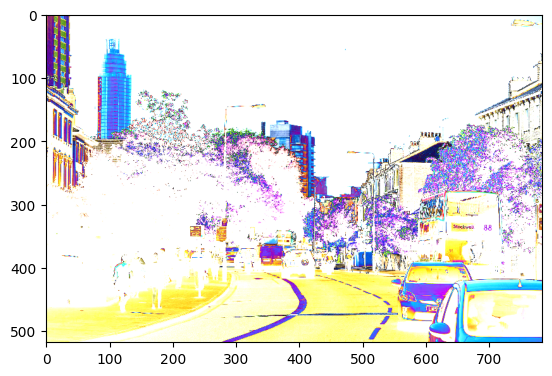

In [85]:
plt.imshow( abs(o.squeeze(axis=0).transpose([1, 2, 0]) ) )

In [483]:
import mlx.optimizers as optim
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        # self.fc1 = nn.Linear(1, 4)
        # self.fc2 = nn.Linear(4, 1)
        self.A = mx.array([2.0])
        self.B = mx.array([1.0])
    def forward(self, x):
        return self.A * x* x + self.B
    def __call__(self, x):
        return self.forward(x)

In [484]:
x = mx.array([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0], [8.0], [9.0], [10.0], [11.0], [12.0]])
y = x ** 2 + 1.0

In [485]:
percep = Perceptron()
optimizer = optim.SGD( learning_rate=0.01)
percep(x=x)

array([[3],
       [9],
       [19],
       ...,
       [201],
       [243],
       [289]], dtype=float32)

In [486]:
def loss_fn(model, x, y):
    pred = model(x)
    return mx.mean((pred - y)**2)

In [487]:
for step in range(2000):
    loss, grads = nn.value_and_grad(percep, loss_fn)(percep, x, y)
    optimizer.update(percep, grads)
    percep = percep

In [488]:
percep(x=x)

array([[nan],
       [nan],
       [nan],
       ...,
       [nan],
       [nan],
       [nan]], dtype=float32)

In [465]:
percep(x = mx.array([[5.0]]))

array([[19.2994]], dtype=float32)

In [446]:
y[3]

array([17], dtype=float32)